## CAS_preprocess_01_py_V2
Use this notebook to execute the equivalent .py script while developing in the cloud.


- This pre processing step first rotates the full frame to flatten the spectrum using rotations transformation.
- Following rotation, the image is affine transformed to straighten the skew in the slit due to the prism.
- Acquire a calibration sequence after any modifications to the system or at the start of every month if no modifications are made.
    - Turn on all lasers and acquire a short sequence at full frame.
- Inputs: 
    - Calibration sequence (folder in data/session_id/fib/ called CalibrationFiles) containing:
       - session_params.csv: csv containing camera parameters for width, height, Xoffset, and Yoffset
        - Tiffs: a subfolder with tiffs named Tiffs0.tif, Tiffs1.tif, Tiffs2.tif, etc
- Outputs: 
    - CalibrationImage.tiff: a .tiff file with the final calibrated image.
    - calibration.txt: a .txt file with the transformation points.

## Setup

### Dependencies

In [3]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
from natsort import natsorted
from PIL import Image
from scipy.signal import find_peaks
import cv2 as cv
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
import CAS_preprocess_01_fibercoupled as unskew_image

warnings.filterwarnings("ignore")
%matplotlib inline

### Constants

In [15]:
SAT_VAL = 7000 # saturation value of camera
FIBER_WIDTH = 40 # width of fiber (in pixels)

## Functions

In [13]:
# def load_session_paths(data_dir, session_id):
#     """Create paths to session data and calibration files."""
#     path = os.path.join(data_dir, session_id)
#     calib_path = os.path.join(path, 'fib/CalibrationFiles')
#     return path, calib_path


# def load_calibration_metadata(calib_path):
#     """Load session_params CSV from calibration folder."""
#     metadata_files = glob.glob(os.path.join(calib_path, '*.csv'))
#     session_params_file = [f for f in metadata_files if 'session_params' in os.path.basename(f)]
    
#     if not session_params_file:
#         raise FileNotFoundError(f"No session_params CSV file found in {calib_path}")
    
#     metadata = pd.read_csv(session_params_file[0])
#     return metadata


# def load_and_average_tiff(tiff_dir):
#     """Load multi-frame TIFF and average frames into a 2D image."""
#     tiff_files = np.array(natsorted(os.listdir(tiff_dir)))
    
#     # Filter for TIFF files only
#     tiff_files = [f for f in tiff_files if f.lower().endswith(('.tif', '.tiff'))]
    
#     if not tiff_files:
#         raise FileNotFoundError(f"No TIFF files found in {tiff_dir}")
    
#     tiff_file_path = os.path.join(tiff_dir, tiff_files[0])
#     tiff = Image.open(tiff_file_path)

#     image_sequence = []
#     while True:
#         try:
#             image_sequence.append(np.array(tiff))
#             tiff.seek(tiff.tell() + 1)
#         except EOFError:
#             break

#     img = np.array(image_sequence)
#     img2d = img.mean(axis=0)
#     return img2d


# def find_laser_positions(img, height_thresh=2000, dist_thresh=100, sat_val=SAT_VAL):
#     """Find horizontal and vertical positions of lasers in the image."""
#     img_to_unskew = np.array(img)
#     h_line = np.mean(img_to_unskew, axis=0)
#     h_peaks, _ = find_peaks(h_line, height=height_thresh, distance=dist_thresh)

#     v_peaks = np.zeros_like(h_peaks, dtype=int)
    
#     # sat_val = 12000
#     for i, x in enumerate(h_peaks):
#         v_line = img_to_unskew[:, x].copy()
#         v_line[v_line < sat_val] = 0
#         idx = np.nonzero(np.diff(v_line))[0]
        
#         if len(idx) >= 2:  # Need at least 2 edges
#             v_peaks[i] = int(np.round((idx[0] + idx[-1]) / 2))
#         else:
#             print(f"Warning: Could not find edges for laser at x={x}")
            
#     return h_peaks, v_peaks, img_to_unskew


# def rotate_image(img, h_peaks, v_peaks):
#     """Rotate image to align lasers horizontally."""
#     if len(h_peaks) < 2 or len(v_peaks) < 2:
#         raise ValueError(f"Not enough laser peaks found. Found {len(h_peaks)} horizontal and {len(v_peaks)} vertical peaks.")
    
#     theta_r = np.rad2deg(np.arctan(
#         (v_peaks[-2] - v_peaks[0]) / (h_peaks[-2] - h_peaks[0])
#     ))
#     rows, cols = img.shape
#     M = cv.getRotationMatrix2D(((cols-1)/2.0, (rows-1)/2.0), theta_r, 1)
#     img_rotated = cv.warpAffine(img, M, (cols, rows))
#     return img_rotated, theta_r


# def analyze_laser(img, h_peaks_rot, use_laser, sat_val=SAT_VAL, fiber_width=FIBER_WIDTH):
#     """Find vertical and horizontal boundaries of a laser fiber."""
#     # Check if use_laser index is valid
#     if use_laser >= len(h_peaks_rot):
#         raise IndexError(f"use_laser={use_laser} but only {len(h_peaks_rot)} lasers detected")
    
#     # Vertical
#     #v_line = img_copy[:, h_peaks_rot[use_laser]]
#     v_line = img[:, h_peaks_rot[use_laser]].copy()
#     v_line[v_line < sat_val] = 0
#     idx = np.nonzero(np.diff(v_line))[0]
    
#     if len(idx) < 2:
#         raise ValueError(f"Could not find edges for laser {use_laser}")
        
#     v_width = [int(idx[0]), int(idx[-1])]

#     # Horizontal
#     h_width = []
#     for position in [v_width[0] + 5, v_width[1] - 5]:
#         h_start = max(0, h_peaks_rot[use_laser] - fiber_width)
#         h_end = min(img.shape[1], h_peaks_rot[use_laser] + fiber_width)
#         h_line = img[position, h_start:h_end].copy() 
#         h_line[h_line < sat_val] = 0
#         h_edges = np.nonzero(np.diff(h_line))[0]
        
#         if len(h_edges) < 1:
#             raise ValueError(f"Could not find horizontal edges for laser {use_laser} at position {position}")
        
#         h_width.append(int(h_peaks_rot[use_laser]-fiber_width + h_edges[0]))

#     return v_width, h_width


# def perform_affine_transform(img_rotated, points_src, points_dst):
#     """Apply affine transformation to align fibers."""
#     pts1 = np.float32(points_src)
#     pts2 = np.float32(points_dst)
#     M = cv.getAffineTransform(pts1, pts2)
#     rows, cols = img_rotated.shape
#     img_final = cv.warpAffine(img_rotated, M, (cols, rows))
#     return img_final


# def store_fiber_boundaries(img_final, h_peaks_final, use_laser, sat_val=SAT_VAL):
#     """Find relative pixel locations of each fiber."""
#     if use_laser >= len(h_peaks_final):
#         raise IndexError(f"use_laser={use_laser} but only {len(h_peaks_final)} lasers detected in final image")
    
#     v_line = img_final[:,h_peaks_final[use_laser]].copy()
#     v_line[v_line < sat_val] = 0
#     idx = np.nonzero(np.diff(v_line))[0]
    
#     if len(idx) < 2:
#         raise ValueError(f"Could not find fiber edges for laser {use_laser}")
        
#     v_width = [int(idx[0]), int(idx[-1])]
    
#     fiber1 = [v_width[0] + 20, v_width[0] + 40]
#     fiber2 = [v_width[1] - 40, v_width[1] - 20]
#     return fiber1, fiber2


# def save_results(img_final, theta_r, points, fiber_bounds, Xoffset, Yoffset, results_dir):
#     """Save transformed TIFF and calibration points."""
#     results_dir.mkdir(parents=True, exist_ok=True)
#     output_file = results_dir / "CalibrationImage.tiff"
#     cv.imwrite(str(output_file), img_final.astype(int))
#     # cv.imwrite(str(output_file), img_final.astype(uint16)) # should we use uint16 since it's a 16-bit image?

#     with open(results_dir / 'calibration.txt', 'w') as f:
#         f.write(f'rot_tform_thetaR = {theta_r}\n')
#         for i, pt in enumerate(points, 1):
#             f.write(f'aff_tform_pt{i} = {pt}\n')
#         f.write(f'fiber1_pixels = {fiber_bounds[0]}\n')
#         f.write(f'fiber2_pixels = {fiber_bounds[1]}\n')
#         f.write(f'calib_Xoffset = {Xoffset}\n')
#         # f.write(f'calib_Yoffset = {Yoffset}\n')  # Also save Yoffset
    
#     print(f"Results saved to {results_dir}")
#     print(f"  - CalibrationImage.tiff")
#     print(f"  - calibration.txt")

## Main

In [16]:
print("Starting HSFP image calibration processing...")
        
# Settings
data_dir = r"C:\output_data\\"

# Get session ID
# session_id = os.listdir(data_dir)[0]
session_id = "815738_2025-11-25T11_19_02.6493184-08_00"
path, calib_path = unskew_image.load_session_paths(data_dir, session_id)
metadata = unskew_image.load_calibration_metadata(calib_path)
tiff_dir = os.path.join(calib_path, 'Tiffs')
img2d = unskew_image.load_and_average_tiff(tiff_dir)

# Camera offsets
Xoffset = int(metadata.XOffset[0])
Yoffset = int(metadata.YOffset[0])

# Find laser positions
h_peaks, v_peaks, img_to_unskew = unskew_image.find_laser_positions(img2d)

# Rotate image
img_rotated, theta_r = unskew_image.rotate_image(img_to_unskew, h_peaks, v_peaks)

# Calculate centers of each laser after rotation
h_line = np.mean(img_rotated, axis=0)
h_peaks_rot, _ = find_peaks(h_line, height=2000, distance=50)

v_peaks_rot = np.zeros(np.size(h_peaks_rot))
for i, x in enumerate(h_peaks_rot):
    v_line = img_rotated[:, x].copy()
    v_line[v_line < SAT_VAL] = 0
    idx = np.nonzero(np.diff(v_line))[0]

    if len(idx) >= 2:  # Need at least 2 edges
        v_peaks_rot[i] = int(np.round((idx[0] + idx[-1]) / 2))
    else:
        print(f"Warning: Could not find edges for laser at x={x}")
v_peaks_rot = v_peaks_rot.astype(int)


# Analyze fibers
v_width1, h_width1 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=0)
v_width2, h_width2 = unskew_image.analyze_laser(img_rotated, h_peaks_rot, use_laser=2)

# Define affine points and transform image
pt1, pt2, pt3 = [h_width1[0], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[0], v_width2[0]]
pt4, pt5, pt6 = [h_width1[1], v_width1[0]], [h_width1[1], v_width1[1]], [h_width2[1], v_width2[0]]

img_final = unskew_image.perform_affine_transform(img_rotated, [pt1, pt2, pt3], [pt4, pt5, pt6])


# Store fiber boundaries
h_line_final = np.mean(img_final, axis=0)
h_peaks_final, _ = find_peaks(h_line_final, height=2000, distance=50)

v_peaks_final = np.zeros(np.size(h_peaks_final))
for i, x in enumerate(h_peaks_final):
    v_line = img_final[:, x].copy()
    v_line[v_line < SAT_VAL] = 0
    idx = np.nonzero(np.diff(v_line))[0]

    if len(idx) >= 2:  # Need at least 2 edges
        v_peaks_final[i] = int(np.round((idx[0] + idx[-1]) / 2))
    else:
        print(f"Warning: Could not find edges for laser at x={x}")
v_peaks_final = v_peaks_final.astype(int)

fiber1, fiber2 = unskew_image.store_fiber_boundaries(img_final, h_peaks_final, use_laser=2)

# Save results
pt1[0] = int(pt1[0] + Xoffset)
pt2[0] = int(pt2[0] + Xoffset)
pt3[0] = int(pt3[0] + Xoffset)
pt4[0] = int(pt4[0] + Xoffset)
pt5[0] = int(pt5[0] + Xoffset)
pt6[0] = int(pt6[0] + Xoffset)
pt1[1] = int(pt1[1] + Yoffset)
pt2[1] = int(pt2[1] + Yoffset)
pt3[1] = int(pt3[1] + Yoffset)
pt4[1] = int(pt4[1] + Yoffset)
pt5[1] = int(pt5[1] + Yoffset)
pt6[1] = int(pt6[1] + Yoffset)
fiber1[0] = int(fiber1[0] + Yoffset)
fiber1[1] = int(fiber1[1] + Yoffset)
fiber2[0] = int(fiber2[0] + Yoffset)
fiber2[1] = int(fiber2[1] + Yoffset)

#create a path to the calibration files
results_path = os.path.join(path, 'fib')
results_dir = Path(results_path)
unskew_image.save_results(img_final, theta_r, [pt1, pt2, pt3, pt4, pt5, pt6], [fiber1, fiber2], Xoffset, Yoffset, results_dir)

print("Calibration processing complete.")

Starting HSFP image calibration processing...
Results saved to C:\output_data\815738_2025-11-25T11_19_02.6493184-08_00\fib
  - CalibrationImage.tiff
  - calibration.txt
Calibration processing complete.


## Plots

In [8]:
print("laser 1 fiber boundaries: ")
print(h_width1, v_width1)
print("\nlaser 3 fiber boundaries: ")
print(h_width2, v_width2)

fiber1_sub = [x - Yoffset for x in fiber1]
fiber2_sub = [x - Yoffset for x in fiber2]

print("\nfiber 1 vertical boundaries: ")
print(fiber1_sub)
print("\nfiber 2 vertical boundaries: ")
print(fiber2_sub)

laser 1 fiber boundaries: 
[466, 454] [3, 143]

laser 3 fiber boundaries: 
[774, 760] [6, 140]

fiber 1 vertical boundaries: 
[26, 46]

fiber 2 vertical boundaries: 
[100, 120]


In [9]:
print("horizontal midpoints of lasers on raw, rotated, and final transformed image: ")
print(h_peaks)
print(h_peaks_rot)
print(h_peaks_final)

print("\nvertical midpoints of lasers on raw, rotated, and final transformed image: ")
print(v_peaks)
print(v_peaks_rot)
print(v_peaks_final)

horizontal midpoints of lasers on raw, rotated, and final transformed image: 
[ 473  686  784 1034 1467]
[ 474  685  784 1034 1467]
[ 469  681  775 1026 1450]

vertical midpoints of lasers on raw, rotated, and final transformed image: 
[78 75 73 69  0]
[74 74 73 73 72]
[73 74 73 73 72]


In [ ]:
# Import the values for the laser midpoints from Smrithi's original code
# These values changed slightly with my code because Smrithi was accidentally writing over pixel values on the image 
h_rot_test = np.array([435, 558, 732, 873, 1280])
print(h_rot_test)
h_final_test = np.array([430, 543, 716, 853, 1250])
print(h_final_test)

In [ ]:
# Create 1x3 subplots with different row heights

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Left: Original image with midpoints ---
im0 = axes[0].imshow(img_to_unskew, aspect='auto', vmin=0, vmax=12000)
axes[0].plot(h_peaks, v_peaks, 'ro', markersize=5, label='Laser midpoints')
axes[0].set(title='Calibration Image - Raw', xlabel='Camera pixels', ylabel='Camera pixels')
axes[0].legend()
#cbar0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
#cbar0.set_label('Pixel Intensity')

# --- Middle: Rotated image with midpoints ---
im1 = axes[1].imshow(img_rotated, aspect='auto', vmin=0, vmax=12000)
axes[1].plot(h_peaks_rot, v_peaks_rot, 'ro', markersize=5, label='Laser midpoints')
#axes[1].plot(h_rot_test, v_peaks_rot, 'go', markersize=2, label='Laser midpoints (Smrithi)') # uncomment to view Smrithi's original midpoints
axes[1].set(title='Calibration Image - Rotated', xlabel='Camera pixels', 
            #ylabel='Camera pixels'
           )
axes[1].yaxis.set_visible(False)
axes[1].legend()
#cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04) # uncomment to give plot its own colorbar
#cbar1.set_label('Pixel Intensity')

# --- Right: Final image with midpoints ---
im2 = axes[2].imshow(img_final, aspect='auto', vmin=0, vmax=12000)
axes[2].plot(h_peaks_final, v_peaks_final, 'ro', markersize=5, label='Laser midpoints')
#axes[2].plot(h_final_test, v_peaks_final, 'go', markersize=2, label='Laser midpoints (Smrithi)') # uncomment to view Smrithi's original midpoints

# Add horizontal lines for fiber boundaries
axes[2].axhline((fiber1[0]-Yoffset), color='red', linestyle='--', linewidth=2, label='Fiber 1 Boundaries')
axes[2].axhline((fiber1[1]-Yoffset), color='red', linestyle='--', linewidth=2, 
                #label='Fiber1 Bottom'
               )
axes[2].axhline((fiber2[0]-Yoffset), color='blue', linestyle='--', linewidth=2, label='Fiber 2 Boundaries')
axes[2].axhline((fiber2[1]-Yoffset), color='blue', linestyle='--', linewidth=2, 
                #label='Fiber2 Bottom'
               )

axes[2].set(title='Calibration Image - Final', xlabel='Camera pixels', 
            #ylabel='Camera pixels'
           )
axes[2].yaxis.set_visible(False)
axes[2].legend(loc='upper right')

cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar2.set_label('Pixel Intensity', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

## Compare script output with Smrithi's output

In [9]:
# Compare calibration.txt files
calib_txt = "/data/HSFP_775510_2025-02-20_11-08-27/fib/calibration.txt"
#calib_image = "/results/CalibrationImage_ipynb.tiff"
new_txt = "/results/calibration.txt"


file1 = calib_txt
file2 = new_txt

with open(file1, "r") as f1, open(file2, "r") as f2:
    lines1 = f1.readlines()
    lines2 = f2.readlines()

if lines1 == lines2:
    print("Files are identical")
else:
    print("Files differ")

Files are identical


In [10]:
# Compare calibration images
calib_image = "/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationImage.tiff"
#calib_image = "/results/CalibrationImage_ipynb.tiff"
new_image = "/results/CalibrationImage.tiff"

from skimage import io
img_orig = io.imread(calib_image)
img_new = io.imread(new_image)

# Check shape first
if img_orig.shape != img_new.shape:
    print("Images have different shapes:", img_orig.shape, img_new.shape)
else:
    # Check pixel-by-pixel equality
    identical = np.array_equal(img_orig, img_new)
    print("Images are identical:", identical)

    # If not identical, quantify the differences
    if not identical:
        diff = np.abs(img_orig.astype(float) - img_new.astype(float))
        print("Max pixel difference:", np.max(diff))
        print("Mean pixel difference:", np.mean(diff))
        
        
from skimage.metrics import structural_similarity as ssim

ssim_value = ssim(img_orig, img_new, data_range=img_new.max() - img_new.min())
print("SSIM:", ssim_value)


Images are identical: False
Max pixel difference: 11517.0
Mean pixel difference: 5.516013730761122
SSIM: 0.9941649232754507


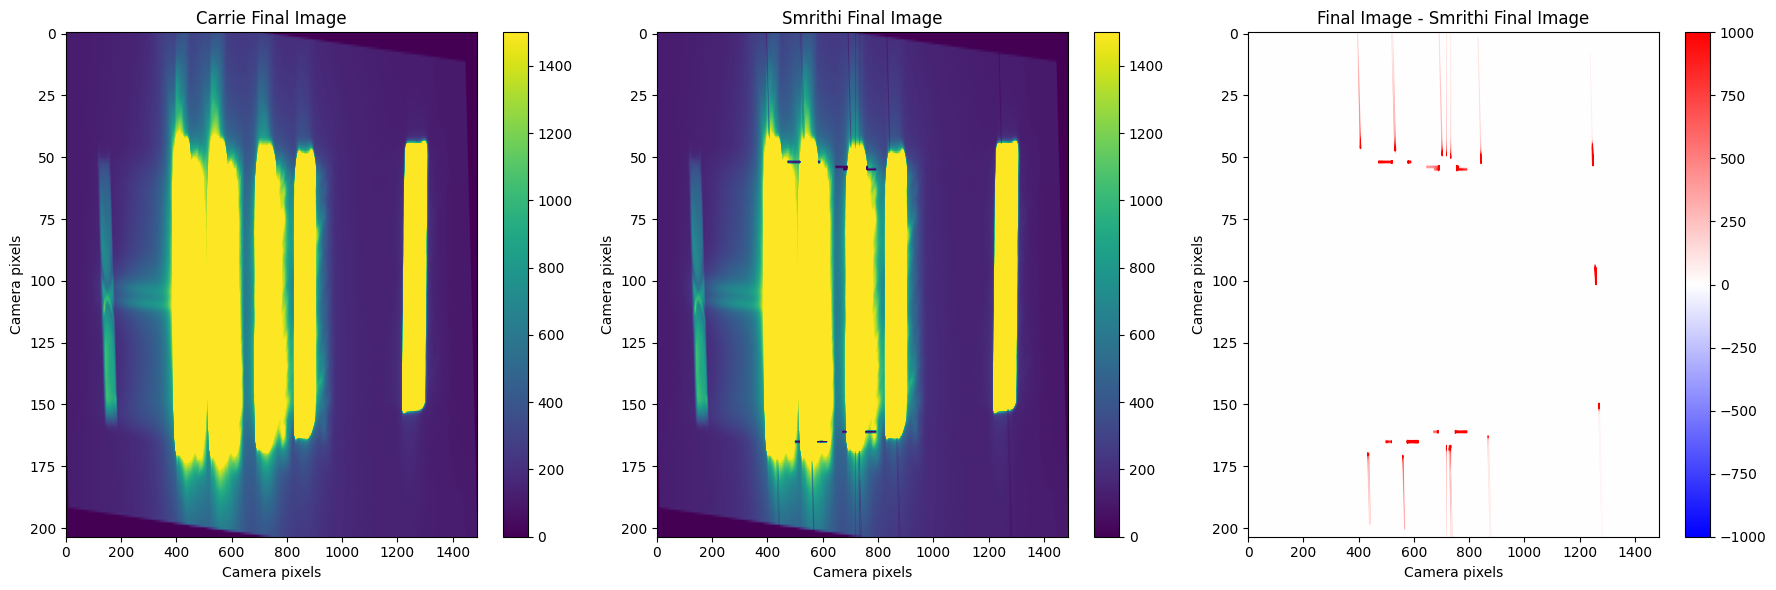

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot img_new
im0 = axes[0].imshow(img_new, aspect='auto', vmin=0, vmax=1500)
axes[0].set(title='Carrie Final Image', xlabel='Camera pixels', ylabel='Camera pixels')
fig.colorbar(im0, ax=axes[0])

# Plot img_orig
im1 = axes[1].imshow(img_orig, aspect='auto', vmin=0, vmax=1500)
axes[1].set(title='Smrithi Final Image', xlabel='Camera pixels', ylabel='Camera pixels')
fig.colorbar(im1, ax=axes[1])

# Plot difference
im2 = axes[2].imshow((img_new - img_orig), aspect='auto', cmap='bwr', vmin=-1000, vmax=1000) 
axes[2].set(title='Final Image - Smrithi Final Image', xlabel='Camera pixels', ylabel='Camera pixels')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()